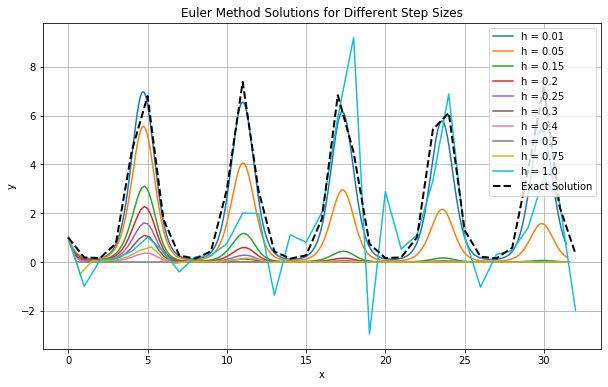

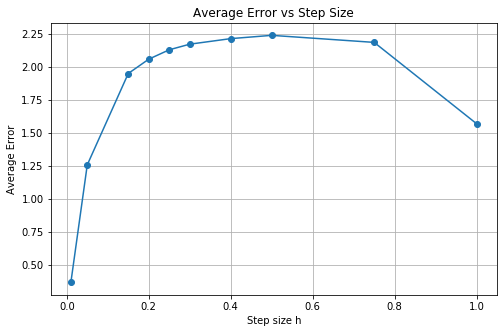

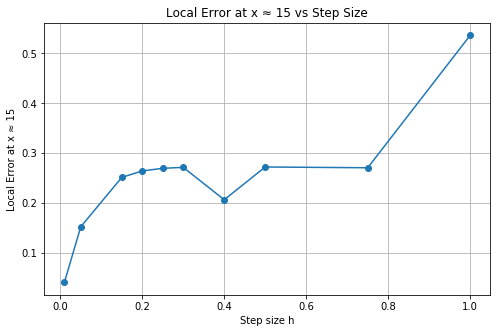

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2*y*np.cos(x)

def exact(x):
    return np.exp(-2*np.sin(x))

h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1.0]

x_start = 0
x_end = 10*np.pi
target_x = 15

avg_errors = []
local_errors = []
y_at_15 = []

plt.figure(figsize=(10, 6))

for h in h_values:
    x_vals = np.arange(x_start, x_end + h, h)
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = 1

    for i in range(len(x_vals) - 1):
        y_vals[i+1] = y_vals[i] + h*f(x_vals[i], y_vals[i])

    y_exact = exact(x_vals)

    error = np.abs(y_exact - y_vals)
    avg_error = np.mean(error)

    avg_errors.append(avg_error)

    index_15 = np.argmin(np.abs(x_vals - target_x))
    local_error = abs(y_exact[index_15] - y_vals[index_15])

    local_errors.append(local_error)
    y_at_15.append(y_vals[index_15])

    plt.plot(x_vals, y_vals, label="h = " + str(h))

plt.plot(x_vals, exact(x_vals), 'k--', linewidth=2, label="Exact Solution")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler Method Solutions for Different Step Sizes")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_errors, marker='o')
plt.xlabel("Step size h")
plt.ylabel("Average Error")
plt.title("Average Error vs Step Size")
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(h_values, local_errors, marker='o')
plt.xlabel("Step size h")
plt.ylabel("Local Error at x ≈ 15")
plt.title("Local Error at x ≈ 15 vs Step Size")
plt.grid(True)
plt.show()

In [3]:
print("Comparison near x = 15")
print("--------------------------------")
print("h\t x closest to 15\t Euler y\t Exact y\t Local Error")

for i in range(0, len(h_values)):
    
    h = h_values[i]
    
    # rebuild x values again (not efficient, but very normal student move)
    x_vals = np.arange(x_start, x_end + h, h)
    
    # manually find closest x to 15
    closest_index = 0
    smallest_diff = abs(x_vals[0] - target_x)
    
    for j in range(1, len(x_vals)):
        diff = abs(x_vals[j] - target_x)
        if diff < smallest_diff:
            smallest_diff = diff
            closest_index = j

    x_close = x_vals[closest_index]
    
    # just reuse stored values instead of recomputing everything
    y_euler_val = y_at_15[i]
    y_exact_val = exact(x_close)
    error_val = local_errors[i]

    # print in a more basic way
    print(str(h) + "\t " + str(round(x_close, 4)) + "\t\t " 
          + str(round(y_euler_val, 6)) + "\t " 
          + str(round(y_exact_val, 6)) + "\t " 
          + str(round(error_val, 6)))

Comparison near x = 15
--------------------------------
h	 x closest to 15	 Euler y	 Exact y	 Local Error
0.01	 15.0		 0.23144	 0.272375	 0.040935
0.05	 15.0		 0.119869	 0.272375	 0.152506
0.15	 15.0		 0.020921	 0.272375	 0.251454
0.2	 15.0		 0.007903	 0.272375	 0.264472
0.25	 15.0		 0.002662	 0.272375	 0.269713
0.3	 15.0		 0.000753	 0.272375	 0.271622
0.4	 14.8		 1.8e-05	 0.206696	 0.206679
0.5	 15.0		 0.0	 0.272375	 0.272375
0.75	 15.0		 0.001574	 0.272375	 0.270801
1.0	 15.0		 0.808593	 0.272375	 0.536218


In [ ]:
# As the step size h increases, the error in Euler’s method grows quickly, with small values like h=0.01 
# staying fairly close to the exact solution while larger values drift far off. This happens because Euler’s 
# method is only a first-order approximation and cannot accurately follow the curvature of the solution when 
# the steps are too large, especially for an oscillating function like this one. By the time h gets near 1, the 
# solution becomes very inaccurate and even unstable, showing how sensitive Euler’s method is to step size.